
红葡萄酒数据集基本信息：
- 总样本数：1599
- 训练集样本数：1279
- 测试集样本数：320
- 品质等级范围：3 - 8

白葡萄酒数据集基本信息：
- 总样本数：4898
- 训练集样本数：3918
- 测试集样本数：980
- 品质等级范围：3 - 9

红葡萄酒线性回归评估结果：
- 测试集准确率（80%训练+20%测试）：0.5969
- 5重交叉验证准确率：0.5847

白葡萄酒线性回归评估结果：
- 测试集准确率（80%训练+20%测试）：0.5102
- 5重交叉验证准确率：0.5065

红/白葡萄酒数据集线性回归品质评估汇总
葡萄酒类型 测试集准确率 5重交叉验证准确率
 红葡萄酒 0.5969    0.5847
 白葡萄酒 0.5102    0.5065


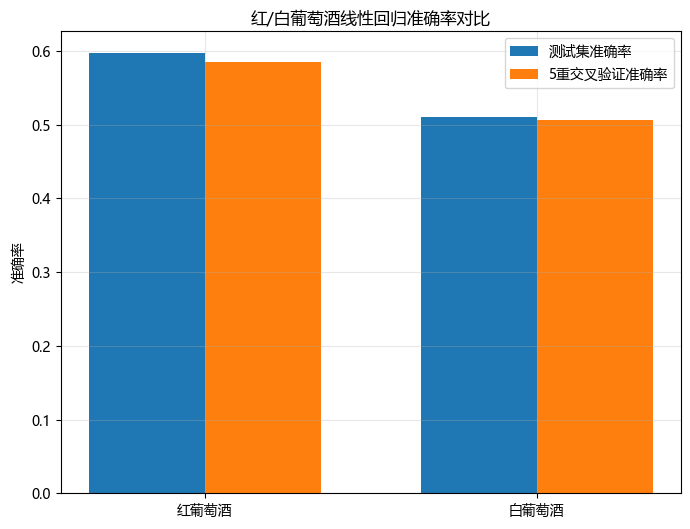

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# --------------------------
# 1. 加载并预处理红/白葡萄酒数据集
# --------------------------
red_wine = pd.read_csv('D:/notebook文件/实验1/winequality-red.csv', sep=';')
white_wine = pd.read_csv('D:/notebook文件/实验1/winequality-white.csv', sep=';')

def process_wine_data(df, wine_type):
    X = df.drop('quality', axis=1)
    y = df['quality']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n{wine_type}数据集基本信息：")
    print(f"- 总样本数：{len(df)}")
    print(f"- 训练集样本数：{len(X_train)}")
    print(f"- 测试集样本数：{len(X_test)}")
    print(f"- 品质等级范围：{y.min()} - {y.max()}")
    
    return X_train, X_test, y_train, y_test, X_scaled, y

red_train, red_test, red_y_train, red_y_test, red_X_all, red_y_all = process_wine_data(red_wine, "红葡萄酒")
white_train, white_test, white_y_train, white_y_test, white_X_all, white_y_all = process_wine_data(white_wine, "白葡萄酒")

# --------------------------
# 2. 定义线性回归与准确率计算函数
# --------------------------
def linear_regression_evaluation(X_train, X_test, y_train, y_test, X_all, y_all, wine_type):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_test_pred = lr.predict(X_test)
    y_test_pred_class = np.round(y_test_pred).astype(int)
    y_test_class = y_test.astype(int)
    y_test_pred_class = np.clip(y_test_pred_class, y_test_class.min(), y_test_class.max())
    test_accuracy = accuracy_score(y_test_class, y_test_pred_class)
    
    y_cv_pred = cross_val_predict(lr, X_all, y_all, cv=5)
    y_cv_pred_class = np.round(y_cv_pred).astype(int)
    y_all_class = y_all.astype(int)
    y_cv_pred_class = np.clip(y_cv_pred_class, y_all_class.min(), y_all_class.max())
    cv_accuracy = accuracy_score(y_all_class, y_cv_pred_class)
    
    print(f"\n{wine_type}线性回归评估结果：")
    print(f"- 测试集准确率（80%训练+20%测试）：{test_accuracy:.4f}")
    print(f"- 5重交叉验证准确率：{cv_accuracy:.4f}")
    
    return test_accuracy, cv_accuracy

# --------------------------
# 3. 分别评估红/白葡萄酒数据集
# --------------------------
red_test_acc, red_cv_acc = linear_regression_evaluation(
    red_train, red_test, red_y_train, red_y_test, red_X_all, red_y_all, "红葡萄酒"
)

white_test_acc, white_cv_acc = linear_regression_evaluation(
    white_train, white_test, white_y_train, white_y_test, white_X_all, white_y_all, "白葡萄酒"
)

# --------------------------
# 4. 汇总结果与可视化（指定系统已存在的中文字体）
# --------------------------
print("\n" + "="*60)
print("红/白葡萄酒数据集线性回归品质评估汇总")
print("="*60)
summary = pd.DataFrame({
    "葡萄酒类型": ["红葡萄酒", "白葡萄酒"],
    "测试集准确率": [f"{red_test_acc:.4f}", f"{white_test_acc:.4f}"],
    "5重交叉验证准确率": [f"{red_cv_acc:.4f}", f"{white_cv_acc:.4f}"]
})
print(summary.to_string(index=False))

# 可视化设置（使用微软雅黑字体，Windows系统默认存在）
plt.rcParams["font.family"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

labels = ["红葡萄酒", "白葡萄酒"]
test_accs = [red_test_acc, white_test_acc]
cv_accs = [red_cv_acc, white_cv_acc]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, test_accs, width, label='测试集准确率')
rects2 = ax.bar(x + width/2, cv_accs, width, label='5重交叉验证准确率')

ax.set_ylabel('准确率')
ax.set_title('红/白葡萄酒线性回归准确率对比')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SimpleImputer  # 正确导入
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. 加载数据
train_data = pd.read_csv('D:/notebook文件/实验1/train.csv')
test_data = pd.read_csv('D:/notebook文件/实验1/test.csv')

# 2. 数据预处理
X = train_data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_data['Survived']

X_test = test_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_ids = test_data['PassengerId']

# 特征分类
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# 预处理管道
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),  # 数值型填充
            ('scaler', StandardScaler())
        ])),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),  # 分类型填充
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]))
    ]
)

# 划分数据集
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 构建并训练模型
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
model.fit(X_train, y_train)

# 验证与预测
y_pred = model.predict(X_val)
print(f"验证集准确率: {accuracy_score(y_val, y_pred):.4f}")

test_pred = model.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_pred
})
submission.to_csv('D:/notebook文件/实验1/titanic_submission.csv', index=False)
print("预测结果已保存到指定路径")